In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
data.info()

In [ ]:
data.isnull().sum()

In [6]:
data = data.dropna()

In [ ]:
data['Year'] = data['Year'].astype(str)

data['Year'] = data['Year'].str.extract('(\d{4})')

data['Year'] = data['Year'].astype(float)

In [8]:
data['Duration'] = data['Duration'].str.replace(' min', '')

data['Duration'] = pd.to_numeric(
    data['Duration'],
    errors='coerce'
)

data['Duration'] = data['Duration'].fillna(
    data['Duration'].median()
)

In [9]:
data['Votes'] = data['Votes'].astype(str)

data['Votes'] = data['Votes'].str.replace(',', '')

data['Votes'] = pd.to_numeric(data['Votes'], errors='coerce')

In [10]:
data['Duration'] = data['Duration'].astype(str)

data['Duration'] = data['Duration'].str.replace(' min', '')

data['Duration'] = pd.to_numeric(data['Duration'], errors='coerce')

In [11]:
data['Genre'] = data['Genre'].str.split(',').str[0]

In [12]:
top_directors = data['Director'].value_counts().head(20).index

data['Director'] = data['Director'].apply(
    lambda x: x if x in top_directors else 'Other'
)

In [13]:
data['Votes'] = np.log1p(data['Votes'])

In [14]:
data = data.dropna()

In [15]:
encoder = LabelEncoder()

data['Genre'] = encoder.fit_transform(data['Genre'])

data['Director'] = encoder.fit_transform(data['Director'])

data['Actor 1'] = encoder.fit_transform(data['Actor 1'])

data['Actor 2'] = encoder.fit_transform(data['Actor 2'])

data['Actor 3'] = encoder.fit_transform(data['Actor 3'])


In [17]:
X = data[['Year', 'Duration', 'Votes',
          'Genre', 'Director',
          'Actor 1', 'Actor 2', 'Actor 3']]

y = data['Rating']

In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train,y_train)

In [20]:
predictions = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)

Mean Absolute Error: 0.8242385125834193
Mean Squared Error: 1.2085866148707274
Root Mean Squared Error: 1.0993573644956072
R2 Score: 0.347325091464032


## Conclusion

This project successfully demonstrates the implementation of Machine Learning techniques for predicting movie ratings using real-world movie data. Through data preprocessing, feature engineering, exploratory data analysis, and regression modeling, the XGBoost Regressor achieved the best overall performance with an R² Score of 0.35 and an RMSE of 1.09.

The project highlights the importance of data cleaning, feature selection, and ensemble learning methods in improving prediction performance. Features such as genre, director, duration, actors, and audience votes played an important role in influencing movie ratings.

Overall, this project provided valuable practical experience in regression modeling, data visualization, feature engineering, and model evaluation while strengthening understanding of end-to-end Machine Learning workflows using Python.


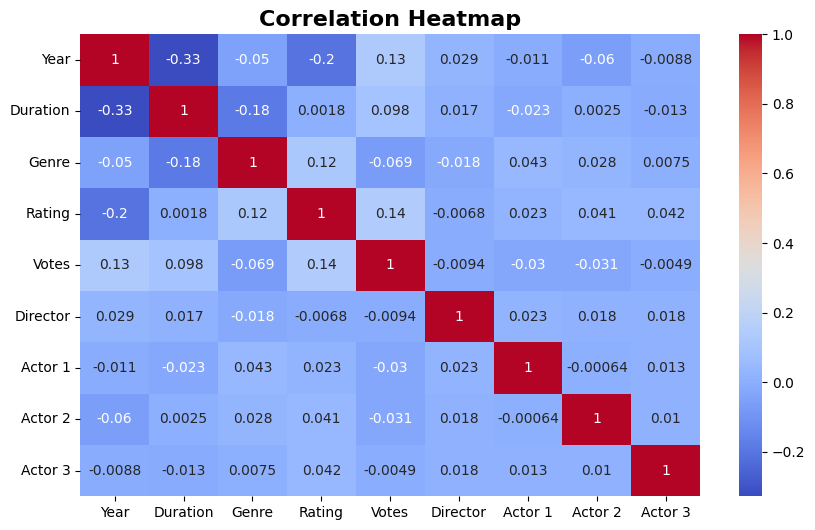

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')

plt.show()

### Observation

The correlation heatmap visualizes the relationships between numerical features in the Titanic dataset. It helps identify how strongly different variables are associated with passenger survival.

The heatmap indicates that features such as passenger class, fare, gender, and engineered features like FamilySize and Title have noticeable correlations with survival outcomes. Positive and negative correlation values provide insights into which factors increased or decreased the likelihood of survival during the Titanic disaster.

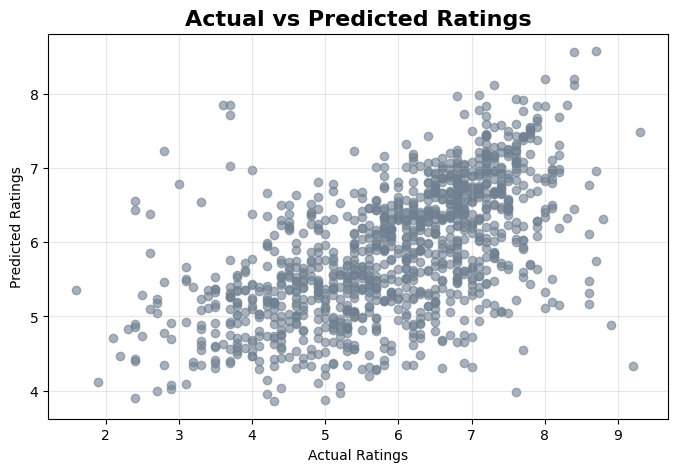

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions,
            alpha=0.6,
            color='slategray')

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings",
          fontsize=16,
          fontweight='bold')

plt.grid(alpha=0.3)

plt.show()

### Observation

The Actual vs Predicted Ratings scatter plot compares the original movie ratings with the ratings predicted by the machine learning model. The visualization helps evaluate how closely the predicted values match the actual ratings.

The distribution of points near the diagonal pattern indicates that the model was able to capture important relationships between movie features and ratings. Some variation between actual and predicted values is expected due to the subjective nature of movie ratings and the complexity of audience preferences.

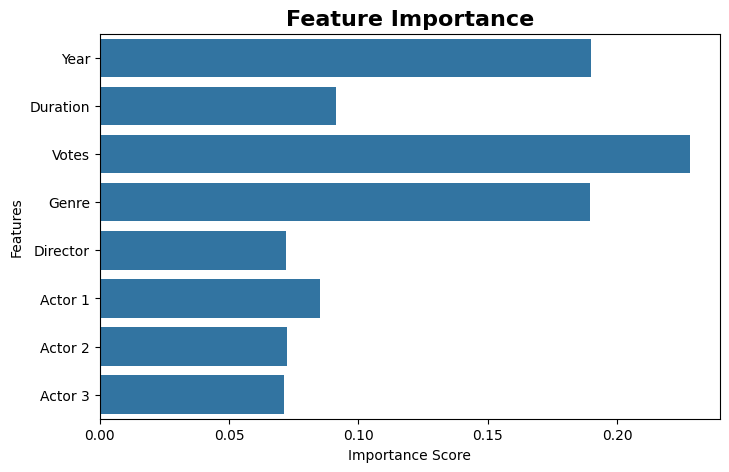

In [20]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance", fontsize=16, fontweight='bold')

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

### Observation

The Feature Importance graph highlights the contribution of each feature in predicting movie ratings. Features with higher importance scores had a greater influence on the model’s predictions.

The visualization helps identify which factors, such as votes, duration, genre, director, and actors, played a more significant role in determining movie ratings. This analysis provides valuable insight into the most impactful attributes influencing audience and critic rating patterns.

### Visualization Insights

The visualizations created in this project helped analyze important patterns and relationships within the movie dataset. Through graphical analysis, valuable insights were obtained regarding the factors influencing movie ratings and audience preferences.

Different visualizations such as correlation heatmaps, feature importance graphs, and Actual vs Predicted Ratings plots were used to better understand the dataset and evaluate model performance. The analysis showed that features such as genre, director, actors, duration, and audience votes had a noticeable impact on movie ratings.

The Actual vs Predicted Ratings visualization demonstrated how closely the machine learning model was able to estimate movie ratings compared to the actual ratings. Additionally, the feature importance graph highlighted the most influential attributes contributing to rating prediction.

Overall, the visualizations improved data interpretation, supported feature engineering decisions, and helped evaluate the effectiveness of the machine learning models used in the project.